In [1]:
# Part 1: Problem Definition and Data Collection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Sydney housing dataset
df = pd.read_csv("../dataset/sydney_housing_sold_properties_100.csv")

# Display the first five records
df.head()

# Check the number of rows and columns
print("Number of properties:", df.shape[0])
print("Number of features/columns:", df.shape[1])

# Number of properties collected from each suburb
suburb_counts = df["suburb"].value_counts()
print(suburb_counts)

# Display the data types of all variables
df.info()

Number of properties: 100
Number of features/columns: 13
suburb
Bondi           40
Parramatta      30
Campbelltown    30
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   property_id           100 non-null    int64  
 1   suburb                100 non-null    object 
 2   postcode              100 non-null    int64  
 3   address               100 non-null    object 
 4   bedrooms              99 non-null     float64
 5   bathrooms             100 non-null    int64  
 6   parking_spaces        80 non-null     float64
 7   listed_area_m2        44 non-null     float64
 8   property_type         100 non-null    object 
 9   sale_date             100 non-null    object 
 10  sale_price_aud        100 non-null    int64  
 11  source_website        100 non-null    object 
 12  source_listing_pages  100 non-

In [2]:
# Count missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

# Check for duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate records:", duplicate_count)

property_id              0
suburb                   0
postcode                 0
address                  0
bedrooms                 1
bathrooms                0
parking_spaces          20
listed_area_m2          56
property_type            0
sale_date                0
sale_price_aud           0
source_website           0
source_listing_pages     0
dtype: int64
Number of duplicate records: 0


In [3]:
# Summary statistics for numerical variables
df.describe()

,property_id,postcode,bedrooms,bathrooms,parking_spaces,listed_area_m2,sale_price_aud
count,100.000000,100.000000,99.000000,100.000000,80.000000,44.000000,1.000000e+02
mean,50.500000,2223.400000,2.464646,1.590000,1.275000,338.934091,1.380205e+06
std,29.011492,227.398196,1.416471,0.792579,0.635948,283.209910,1.363597e+06
min,1.000000,2026.000000,1.000000,1.000000,1.000000,66.000000,4.000000e+05
25%,25.750000,2026.000000,2.000000,1.000000,1.000000,121.750000,6.147500e+05
50%,50.500000,2150.000000,2.000000,1.000000,1.000000,221.500000,9.150000e+05
75%,75.250000,2560.000000,3.000000,2.000000,1.000000,552.350000,1.498750e+06
max,100.000000,2560.000000,12.000000,6.000000,4.000000,1201.000000,8.025000e+06


              count       mean     median     min      max
suburb                                                    
Bondi            40  2344862.5  1810000.0  560000  8025000
Campbelltown     30   868300.0   900000.0  415000  1750000
Parramatta       30   605900.0   624000.0  400000   805000


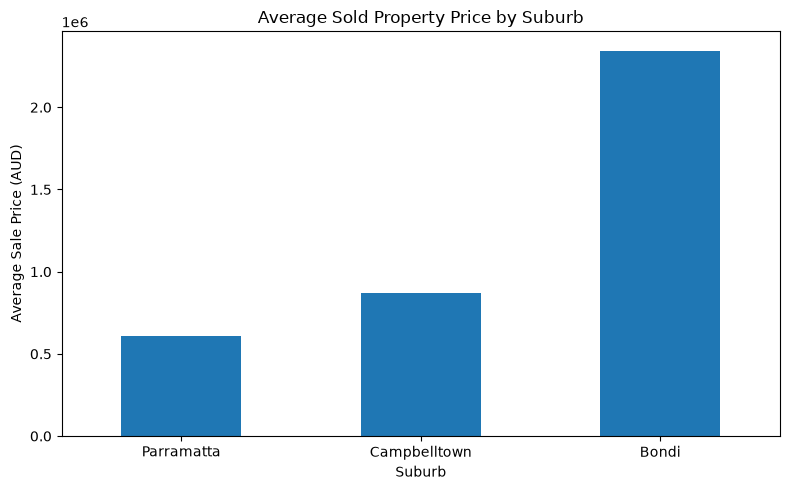

In [4]:
# Compare sale prices across the three suburbs

suburb_summary = df.groupby("suburb")["sale_price_aud"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

print(suburb_summary)

# Average sale price by suburb
plt.figure(figsize=(8, 5))

df.groupby("suburb")["sale_price_aud"].mean().sort_values().plot(
    kind="bar"
)

plt.title("Average Sold Property Price by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Average Sale Price (AUD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

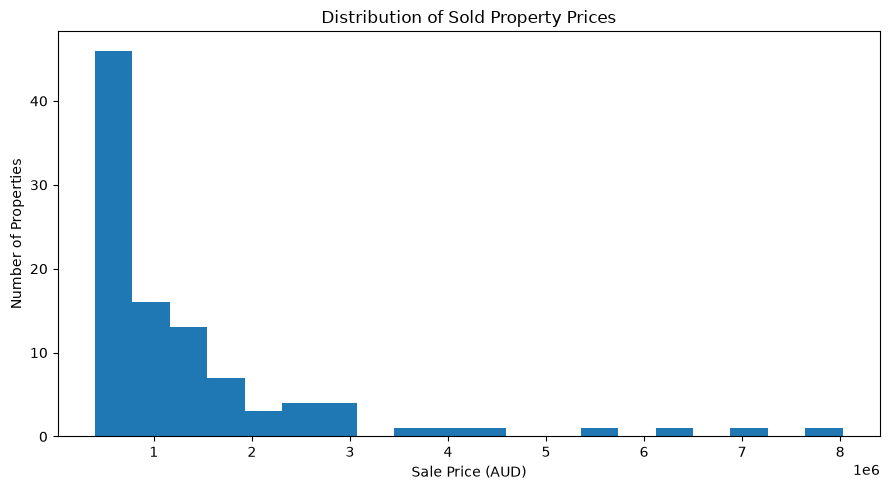

<Figure size 900x600 with 0 Axes>

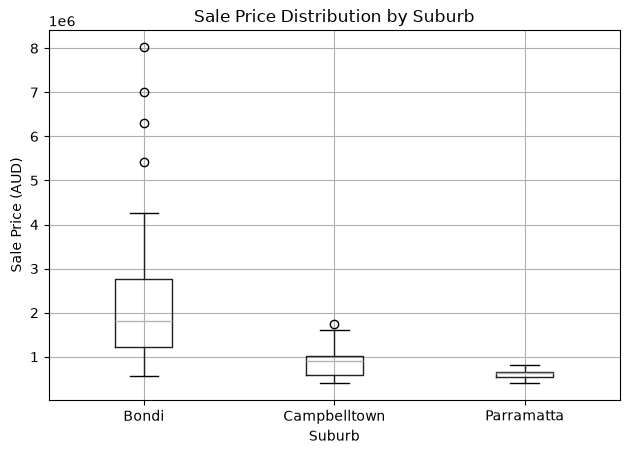

In [5]:
# Distribution of sale prices
plt.figure(figsize=(9, 5))
plt.hist(df["sale_price_aud"], bins=20)
plt.title("Distribution of Sold Property Prices")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")

plt.tight_layout()
plt.show()

# Compare sale price distributions across suburbs
plt.figure(figsize=(9, 6))
df.boxplot(column="sale_price_aud", by="suburb")
plt.title("Sale Price Distribution by Suburb")
plt.suptitle("")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")

plt.tight_layout()
plt.show()

Date range:
Earliest sale: 2025-11-05
Latest sale: 2026-09-12
sale_date
2025-11    3.154500e+06
2025-12    1.272500e+06
2026-02    3.061625e+06
2026-03    1.260750e+06
2026-04    1.630000e+06
2026-05    1.801214e+06
2026-06    1.347000e+06
2026-07    7.231471e+05
2026-08    8.518200e+05
2026-09    9.541667e+05
Freq: M, Name: sale_price_aud, dtype: float64


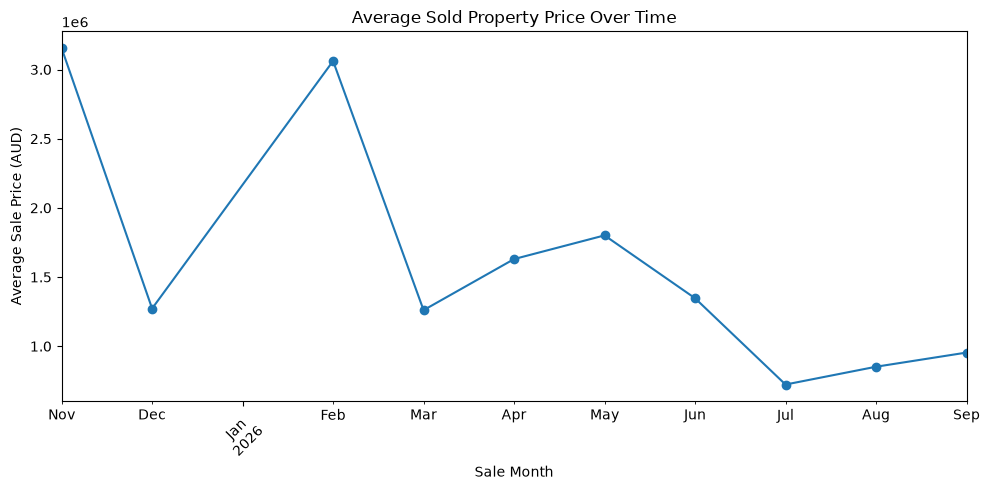

In [6]:
# Convert sale_date to datetime format
df["sale_date"] = pd.to_datetime(df["sale_date"])

print("Date range:")
print("Earliest sale:", df["sale_date"].min().date())
print("Latest sale:", df["sale_date"].max().date())


# Calculate average sale price by month

monthly_prices = (
    df.groupby(df["sale_date"].dt.to_period("M"))["sale_price_aud"]
    .mean()
)

print(monthly_prices)


# Plot average sale price over time
plt.figure(figsize=(10, 5))
monthly_prices.plot(marker="o")

plt.title("Average Sold Property Price Over Time")
plt.xlabel("Sale Month")
plt.ylabel("Average Sale Price (AUD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Number of properties sold in each month
monthly_counts = (
    df.groupby(df["sale_date"].dt.to_period("M"))
    .size()
)

print(monthly_counts)


# Number of properties sold by suburb and month
monthly_suburb_counts = pd.crosstab(
    df["sale_date"].dt.to_period("M"),
    df["suburb"]
)

monthly_suburb_counts

sale_date
2025-11     6
2025-12     2
2026-02     8
2026-03     4
2026-04     5
2026-05     7
2026-06    20
2026-07    17
2026-08    25
2026-09     6
Freq: M, dtype: int64


suburb,Bondi,Campbelltown,Parramatta
sale_date,,,
2025-11,6,0,0
2025-12,2,0,0
2026-02,8,0,0
2026-03,4,0,0
2026-04,5,0,0
2026-05,5,2,0
2026-06,5,15,0
2026-07,0,8,9
2026-08,4,5,16


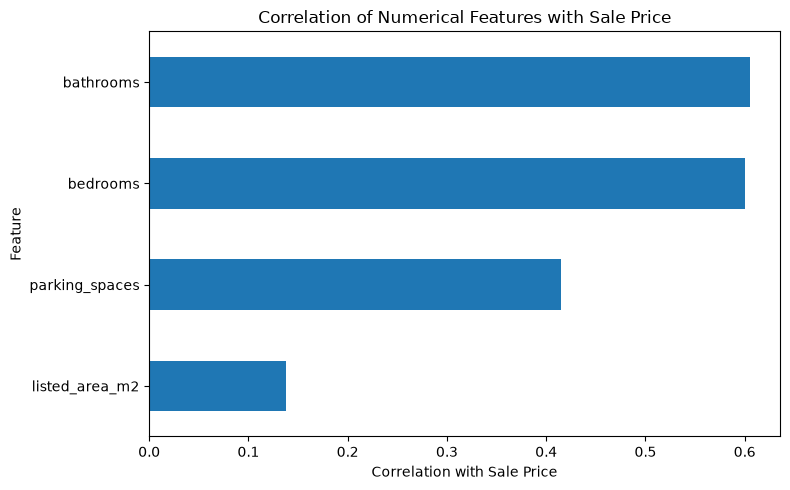

In [8]:
# Correlation between numerical variables and sale price
numeric_columns = [
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "listed_area_m2",
    "sale_price_aud"
]

correlation_matrix = df[numeric_columns].corr()
correlation_matrix["sale_price_aud"].sort_values(ascending=False)


# Visualise correlations with sale price
plt.figure(figsize=(8, 5))

correlation_matrix["sale_price_aud"].drop("sale_price_aud").sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Numerical Features with Sale Price")
plt.xlabel("Correlation with Sale Price")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [9]:
# Compare key property features across suburbs
feature_summary = df.groupby("suburb")[
    ["bedrooms", "bathrooms", "parking_spaces", "listed_area_m2"]
].mean()

print(feature_summary.round(2))


# Median property features across suburbs
median_features = df.groupby("suburb")[
    ["bedrooms", "bathrooms", "parking_spaces", "listed_area_m2"]
].median()

median_features

              bedrooms  bathrooms  parking_spaces  listed_area_m2
suburb                                                           
Bondi             2.69       1.78            1.38          258.96
Campbelltown      2.80       1.50            1.39          509.43
Parramatta        1.83       1.43            1.07          126.20


,bedrooms,bathrooms,parking_spaces,listed_area_m2
suburb,,,,
Bondi,2.0,2.0,1.0,272.0
Campbelltown,3.0,1.0,1.0,553.7
Parramatta,2.0,1.0,1.0,122.0


## Part 1: Problem Definition and Data Collection

The objective of this project is to develop a machine learning regression system that predicts the sale price of residential properties in selected Sydney suburbs. The prediction target is the recorded sale price, while property and location characteristics are used as explanatory variables.

Three suburbs were selected to represent substantially different housing markets: Bondi, Campbelltown and Parramatta. The collected dataset contains 100 sold properties, with 40 properties from Bondi and 30 properties from each of Campbelltown and Parramatta. The observed average sale prices differ substantially between the suburbs, providing useful variation for the prediction problem.

The dataset contains property characteristics including bedrooms, bathrooms, parking spaces, property type and listed area, together with the sale date and suburb. Initial analysis indicates that bedrooms and bathrooms have relatively strong positive correlations with sale price. Suburb is also expected to be an important predictor because the observed sale prices differ substantially between the selected locations.

Several data-quality issues were identified. One bedroom value, 20 parking values and 56 listed-area values are missing. Sale price has no missing observations, which is important because it is the prediction target. No duplicate records were identified. The high proportion of missing area values means this feature will need to be handled carefully during preprocessing.

The dataset also has limitations. The properties were manually collected from publicly available sold-property listings, so the sample may not represent the complete Sydney housing market. The number and suburb composition of observations varies across the collection period, which limits the interpretation of monthly price trends. Property descriptions may also omit information such as renovation quality, land characteristics, views, condition, street position and other factors that can influence sale prices. Therefore, predictions should be interpreted as estimates based on the available features rather than exact property valuations.

In [10]:
# Create a data-quality summary
data_quality = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": (df.isnull().mean() * 100).round(1).values
})

data_quality

,Column,Data_Type,Missing_Count,Missing_Percentage
0,property_id,int64,0,0.0
1,suburb,object,0,0.0
2,postcode,int64,0,0.0
3,address,object,0,0.0
4,bedrooms,float64,1,1.0
5,bathrooms,int64,0,0.0
6,parking_spaces,float64,20,20.0
7,listed_area_m2,float64,56,56.0
8,property_type,object,0,0.0
9,sale_date,datetime64[ns],0,0.0


## Part 2: Data Understanding and Feature Engineering

This section explores the distribution of housing prices, differences between the selected suburbs, trends over time, property characteristics, and potential outliers. The analysis is used to identify important variables that are expected to influence sale prices before feature engineering. Feature engineering is then applied to prepare the data for predictive modelling.

In [11]:
# Identify potential outliers using the IQR method
Q1 = df["sale_price_aud"].quantile(0.25)
Q3 = df["sale_price_aud"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[
    (df["sale_price_aud"] < lower_bound) |
    (df["sale_price_aud"] > upper_bound)
]

print("\nNumber of potential outliers:", len(outliers))

outliers[
    ["suburb", "address", "bedrooms", "bathrooms",
     "parking_spaces", "property_type", "sale_price_aud"]
].sort_values("sale_price_aud", ascending=False)

Q1: 614750.0
Q3: 1498750.0
IQR: 884000.0
Lower bound: -711250.0
Upper bound: 2824750.0

Number of potential outliers: 9


,suburb,address,bedrooms,bathrooms,parking_spaces,property_type,sale_price_aud
39,Bondi,"16 Boonara Avenue, Bondi",3.0,2,4.0,House,8025000
25,Bondi,"1-6/3 Moore Street, Bondi",12.0,6,1.0,Block of units,7000000
29,Bondi,"2 Denham Street, Bondi",4.0,3,3.0,House,6308000
10,Bondi,"14 Anglesea Street, Bondi",6.0,4,1.0,House,5416000
9,Bondi,"38 Philip Street, Bondi",3.0,2,NaN,House,4260000
7,Bondi,"3 Flood Street, Bondi",4.0,2,1.0,House,4001000
2,Bondi,"6 Miller Street, Bondi",3.0,2,3.0,House,3500000
36,Bondi,"2/15 New Street, Bondi",2.0,3,1.0,House,3000000
38,Bondi,"3 Orr Street, Bondi",3.0,1,NaN,House,2910000


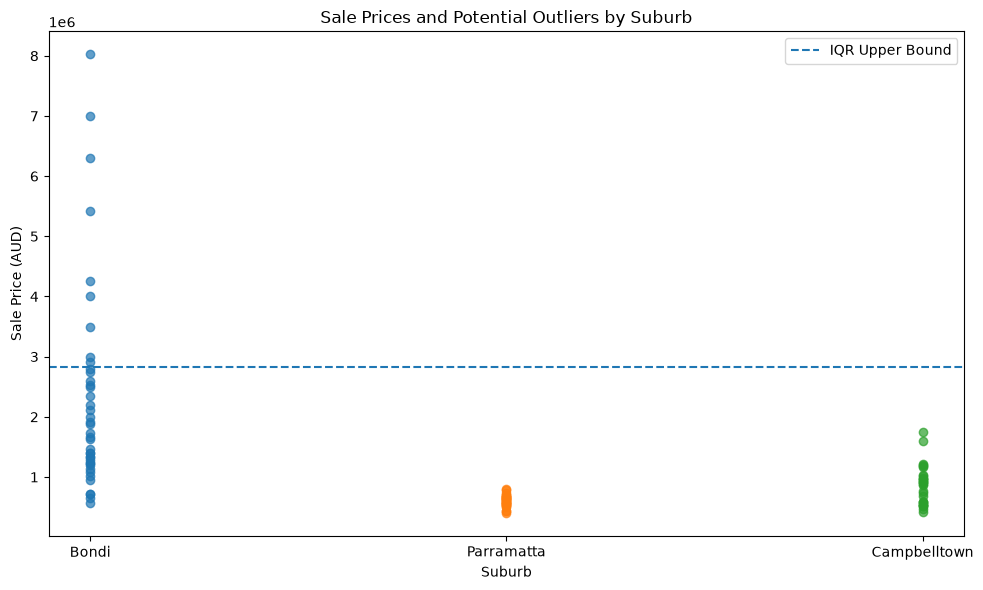

,suburb,address,bedrooms,bathrooms,parking_spaces,property_type,sale_price_aud
39,Bondi,"16 Boonara Avenue, Bondi",3.0,2,4.0,House,8025000
25,Bondi,"1-6/3 Moore Street, Bondi",12.0,6,1.0,Block of units,7000000
29,Bondi,"2 Denham Street, Bondi",4.0,3,3.0,House,6308000
10,Bondi,"14 Anglesea Street, Bondi",6.0,4,1.0,House,5416000
9,Bondi,"38 Philip Street, Bondi",3.0,2,NaN,House,4260000
7,Bondi,"3 Flood Street, Bondi",4.0,2,1.0,House,4001000
2,Bondi,"6 Miller Street, Bondi",3.0,2,3.0,House,3500000
36,Bondi,"2/15 New Street, Bondi",2.0,3,1.0,House,3000000
38,Bondi,"3 Orr Street, Bondi",3.0,1,NaN,House,2910000
26,Bondi,"5211/34 Wellington Street, Bondi",3.0,2,2.0,Apartment,2800000


In [12]:
# Sale price by suburb with potential outliers highlighted
plt.figure(figsize=(10, 6))
for suburb in df["suburb"].unique():
    suburb_data = df[df["suburb"] == suburb]
    
    plt.scatter(
        suburb_data["suburb"],
        suburb_data["sale_price_aud"],
        alpha=0.7
    )

plt.axhline(
    upper_bound,
    linestyle="--",
    label="IQR Upper Bound"
)

plt.title("Sale Prices and Potential Outliers by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.legend()

plt.tight_layout()
plt.show()


# Show the highest-priced properties
top_properties = df.nlargest(
    10, "sale_price_aud"
)[[
    "suburb",
    "address",
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "property_type",
    "sale_price_aud"
]]

top_properties

In [13]:
# Feature Engineering: Extract information from sale date
df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month

# Display the new features
df[["sale_date", "sale_year", "sale_month"]].head(10)

# Check the distribution of sales across years and months
print("Sales by year:")
print(df["sale_year"].value_counts().sort_index())

print("\nSales by month:")
print(df["sale_month"].value_counts().sort_index())

Sales by year:
sale_year
2025     8
2026    92
Name: count, dtype: int64

Sales by month:
sale_month
2      8
3      4
4      5
5      7
6     20
7     17
8     25
9      6
11     6
12     2
Name: count, dtype: int64


property_type
Apartment               59
House                   25
Unit                    10
Townhouse                2
Studio                   1
Block of units           1
Duplex/semi-detached     1
Villa                    1
Name: count, dtype: int64
                      count        mean     median      min      max
property_type                                                       
Apartment                59  1090661.02   725000.0   415000  2800000
Block of units            1  7000000.00  7000000.0  7000000  7000000
Duplex/semi-detached      1  1030000.00  1030000.0  1030000  1030000
House                    25  2307860.00  1195000.0   870000  8025000
Studio                    1   560000.00   560000.0   560000   560000
Townhouse                 2   755000.00   755000.0   730000   780000
Unit                     10   518500.00   531500.0   400000   657000
Villa                     1   690000.00   690000.0   690000   690000


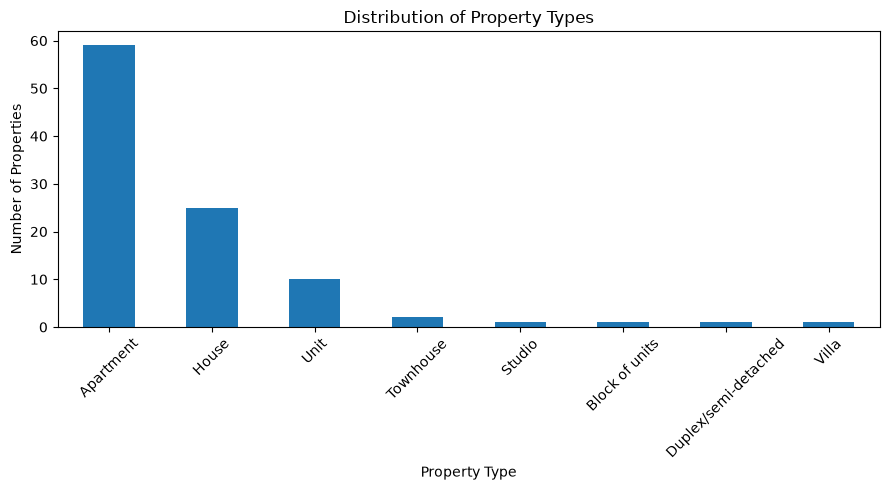

In [14]:
# Property type distribution
property_type_counts = df["property_type"].value_counts()
print(property_type_counts)


# Average sale price by property type
property_type_prices = (
    df.groupby("property_type")["sale_price_aud"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)
print(property_type_prices)

# Visualise property type frequencies
plt.figure(figsize=(9, 5))
property_type_counts.plot(kind="bar")

plt.title("Distribution of Property Types")
plt.xlabel("Property Type")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# Property type distribution across suburbs
suburb_property_types = pd.crosstab(
    df["suburb"],
    df["property_type"]
)

print(suburb_property_types)


# Average sale price by suburb and property type
suburb_type_prices = (
    df.groupby(["suburb", "property_type"])["sale_price_aud"]
    .agg(["count", "mean", "median"])
    .round(2)
)

suburb_type_prices

property_type  Apartment  Block of units  Duplex/semi-detached  House  Studio  \
suburb                                                                          
Bondi                 29               1                     0      9       1   
Campbelltown           6               0                     1     16       0   
Parramatta            24               0                     0      0       0   

property_type  Townhouse  Unit  Villa  
suburb                                 
Bondi                  0     0      0  
Campbelltown           1     5      1  
Parramatta             1     5      0  


count        mean     median
suburb       property_type                                     
Bondi        Apartment                29  1588431.03  1400000.0
             Block of units            1  7000000.00  7000000.0
             House                     9  4463333.33  4001000.0
             Studio                    1   560000.00   560000.0
Campbelltown Apartment                 6   577750.00   587000.0
             Duplex/semi-detached      1  1030000.00  1030000.0
             House                    16  1095406.25   980250.0
             Townhouse                 1   730000.00   730000.0
             Unit                      5   521200.00   533000.0
             Villa                     1   690000.00   690000.0
Parramatta   Apartment                24   617416.67   625500.0
             Townhouse                 1   780000.00   780000.0
             Unit                      5   515800.00   530000.0

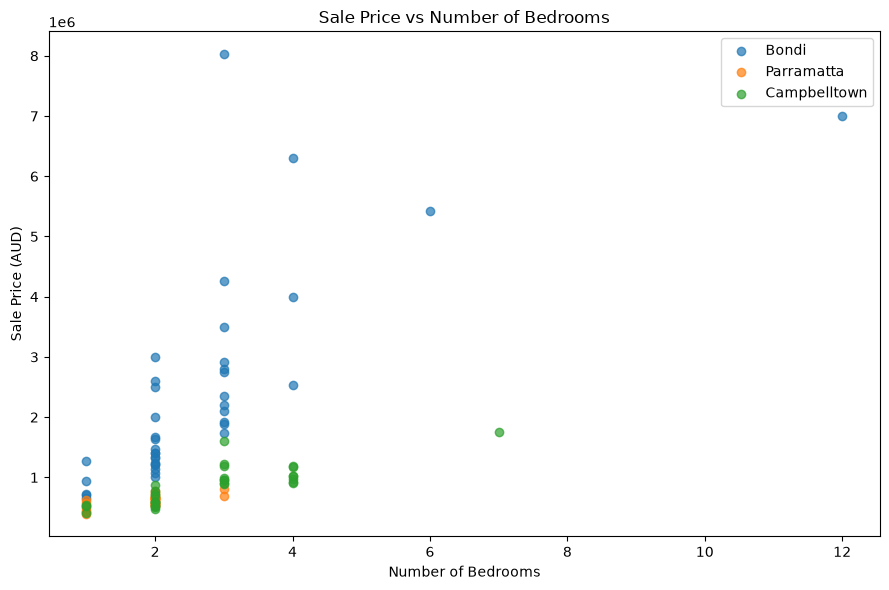

,count,mean,median,min,max
bedrooms,,,,,
1.0,15,619100.00,535000.0,400000,1280000
2.0,49,965051.02,680000.0,469000,3000000
3.0,22,2120954.55,1810000.0,695000,8025000
4.0,10,2005950.00,1100000.0,915000,6308000
6.0,1,5416000.00,5416000.0,5416000,5416000
7.0,1,1750000.00,1750000.0,1750000,1750000
12.0,1,7000000.00,7000000.0,7000000,7000000


In [16]:
# Sale price versus number of bedrooms
plt.figure(figsize=(9, 6))
for suburb in df["suburb"].unique():
    suburb_data = df[df["suburb"] == suburb]
    
    plt.scatter(
        suburb_data["bedrooms"],
        suburb_data["sale_price_aud"],
        label=suburb,
        alpha=0.7
    )

plt.title("Sale Price vs Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price (AUD)")
plt.legend()

plt.tight_layout()
plt.show()


# Average sale price by number of bedrooms
bedroom_summary = (
    df.groupby("bedrooms")["sale_price_aud"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

bedroom_summary

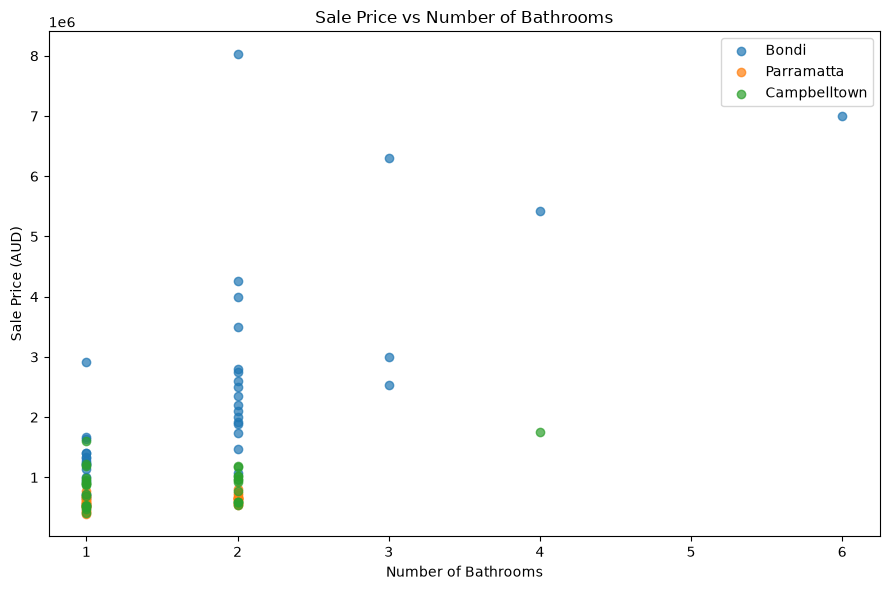

,count,mean,median,min,max
bathrooms,,,,,
1,52,884509.62,719250.0,400000,2910000
2,42,1571952.38,995250.0,547000,8025000
3,3,3946000.00,3000000.0,2530000,6308000
4,2,3583000.00,3583000.0,1750000,5416000
6,1,7000000.00,7000000.0,7000000,7000000


In [17]:
# Sale price versus number of bathrooms
plt.figure(figsize=(9, 6))
for suburb in df["suburb"].unique():
    suburb_data = df[df["suburb"] == suburb]
    
    plt.scatter(
        suburb_data["bathrooms"],
        suburb_data["sale_price_aud"],
        label=suburb,
        alpha=0.7
    )

plt.title("Sale Price vs Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Sale Price (AUD)")
plt.legend()

plt.tight_layout()
plt.show()


# Average sale price by number of bathrooms
bathroom_summary = (
    df.groupby("bathrooms")["sale_price_aud"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

bathroom_summary

In [18]:
# Create a separate dataframe for modelling
model_df = df.copy()
print("Original dataset shape:", model_df.shape)

# Define features and target
features = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "listed_area_m2",
    "sale_year",
    "sale_month"
]

target = "sale_price_aud"

X = model_df[features]
y = model_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Original dataset shape: (100, 15)
Feature matrix shape: (100, 8)
Target shape: (100,)


In [19]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and held-out test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (80, 8)
Testing features: (20, 8)
Training target: (80,)
Testing target: (20,)


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define numerical and categorical features
numeric_features = [
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "listed_area_m2",
    "sale_year",
    "sale_month"
]

categorical_features = [
    "suburb",
    "property_type"
]

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

# Fit preprocessing only on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the held-out test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing pipeline created successfully.
Processed training shape: (80, 16)
Processed testing shape: (20, 16)


## Part 3: Model Selection and Initial Expectations

Three regression approaches were selected to represent different modelling strategies: Linear Regression, Random Forest Regression and Gradient Boosting Regression.

Linear Regression was selected as a simple and interpretable baseline. It provides a useful reference for determining whether more complex nonlinear models provide meaningful improvements. However, it may be limited because the exploratory analysis indicates that housing prices are influenced by interactions between suburb, property type and property characteristics.

Random Forest Regression was selected because it can model nonlinear relationships and interactions between features without requiring a linear relationship between predictors and sale price. It is also relatively robust to unusual observations compared with a simple linear model.

Gradient Boosting Regression was selected because it builds an ensemble of decision trees sequentially, allowing later trees to focus on correcting previous prediction errors. This approach can capture complex nonlinear relationships in a small structured dataset.

Before training, Gradient Boosting is expected to perform best, followed by Random Forest and then Linear Regression. This expectation is based on the observed differences between suburbs, the nonlinear patterns in the bedroom and bathroom analyses, and the presence of high-value properties. The experimental results will later be compared with these initial expectations.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model 1: Linear Regression
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Model 2: Random Forest Regression
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# Model 3: Gradient Boosting Regression
gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ))
])

print("All three model pipelines created successfully.")

All three model pipelines created successfully.


In [22]:
from sklearn.model_selection import KFold, cross_validate

# Set up 5-fold cross-validation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define evaluation metrics
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# Store the three models
models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

# Perform 5-fold cross-validation
cv_results = {}

for name, model in models.items():
    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring,
        return_train_score=True
    )
    
    cv_results[name] = results
    
    print(f"\n{name}")
    print("Validation MAE:", -results["test_MAE"].mean())
    print("Validation RMSE:", -results["test_RMSE"].mean())
    print("Validation R²:", results["test_R2"].mean())


Linear Regression
Validation MAE: 385915.5818078179
Validation RMSE: 555159.6022650676
Validation R²: 0.7567825409135182

Random Forest
Validation MAE: 275770.6921626984
Validation RMSE: 535514.083892024
Validation R²: 0.7735703554797997

Gradient Boosting
Validation MAE: 287609.1139812358
Validation RMSE: 539389.9242892514
Validation R²: 0.7808491935334092


In [23]:
# Compare training and validation performance
comparison = []
for name, results in cv_results.items():
    comparison.append({
        "Model": name,
        "Train MAE": -results["train_MAE"].mean(),
        "Validation MAE": -results["test_MAE"].mean(),
        "Train RMSE": -results["train_RMSE"].mean(),
        "Validation RMSE": -results["test_RMSE"].mean(),
        "Train R2": results["train_R2"].mean(),
        "Validation R2": results["test_R2"].mean()
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.round(2)

,Model,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,Linear Regression,300961.02,385915.58,406840.37,555159.60,0.88,0.76
1,Random Forest,109579.08,275770.69,230705.72,535514.08,0.96,0.77
2,Gradient Boosting,98473.63,287609.11,152611.19,539389.92,0.98,0.78


In [24]:
# Investigate the effect of Gradient Boosting model complexity
depth_results = []
for depth in [1, 2, 3, 4]:
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=depth,
            random_state=42
        ))
    ])
    
    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring,
        return_train_score=True
    )
    
    depth_results.append({
        "Max Depth": depth,
        "Train R2": results["train_R2"].mean(),
        "Validation R2": results["test_R2"].mean(),
        "Train RMSE": -results["train_RMSE"].mean(),
        "Validation RMSE": -results["test_RMSE"].mean(),
        "Validation MAE": -results["test_MAE"].mean()
    })

depth_df = pd.DataFrame(depth_results)
depth_df.round(3)

,Max Depth,Train R2,Validation R2,Train RMSE,Validation RMSE,Validation MAE
0,1,0.911,0.621,354525.208,701941.589,366961.861
1,2,0.983,0.781,152611.190,539389.924,287609.114
2,3,0.995,0.793,86746.270,503328.283,273076.957
3,4,0.998,0.807,56594.101,471949.727,272379.445


In [25]:
# Update Gradient Boosting using the best tested complexity
gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

print("Final Gradient Boosting model configured with max_depth=4.")


# Train all three final models on the training data
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

# Store the final model configurations
models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

Final Gradient Boosting model configured with max_depth=4.
Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [26]:
# Re-create the final Gradient Boosting model
gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

# Store the final model configurations

models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

# Train all three final models

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_results = []
for name, model in models.items():
    
    # Predict on the held-out test set
    predictions = model.predict(X_test)
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    test_results.append({
        "Model": name,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2
    })

test_results_df = pd.DataFrame(test_results)
test_results_df.round(2)

,Model,Test MAE,Test RMSE,Test R2
0,Linear Regression,765285.16,1256456.33,0.54
1,Random Forest,608712.67,1210536.26,0.57
2,Gradient Boosting,616156.34,1231423.69,0.56


In [28]:
# Generate predictions from the final Gradient Boosting model
best_model = gradient_boosting_model
test_predictions = best_model.predict(X_test)
test_predictions_df = X_test.copy()

test_predictions_df["actual_price"] = y_test.values
test_predictions_df["predicted_price"] = test_predictions

test_predictions_df["absolute_error"] = (
    test_predictions_df["actual_price"] -
    test_predictions_df["predicted_price"]
).abs()

test_predictions_df["percentage_error"] = (
    test_predictions_df["absolute_error"] /
    test_predictions_df["actual_price"]
) * 100

test_predictions_df.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,suburb,property_type,bedrooms,bathrooms,parking_spaces,listed_area_m2,sale_year,sale_month,actual_price,predicted_price,absolute_error,percentage_error
39,Bondi,House,3.0,2,4.0,NaN,2025,11,8025000,3.464541e+06,4.560459e+06,56.828154
77,Campbelltown,House,7.0,4,2.0,510.9,2026,7,1750000,3.785516e+06,2.035516e+06,116.315180
31,Bondi,Studio,NaN,1,NaN,NaN,2026,2,560000,2.274704e+06,1.714704e+06,306.197216
0,Bondi,Apartment,2.0,2,1.0,NaN,2026,9,2600000,1.532728e+06,1.067272e+06,41.048919
10,Bondi,House,6.0,4,1.0,415.0,2026,5,5416000,6.136971e+06,7.209709e+05,13.311871
30,Bondi,Apartment,2.0,2,1.0,NaN,2026,2,2500000,1.947235e+06,5.527652e+05,22.110610
12,Bondi,Apartment,1.0,1,NaN,NaN,2026,5,713500,1.201923e+06,4.884231e+05,68.454536
33,Bondi,Apartment,2.0,2,NaN,NaN,2025,12,1080000,1.471335e+06,3.913352e+05,36.234738
4,Bondi,Apartment,1.0,1,NaN,NaN,2026,8,650000,8.180854e+05,1.680854e+05,25.859288
90,Campbelltown,House,3.0,1,1.0,815.0,2026,6,1220000,1.062725e+06,1.572754e+05,12.891428


In [29]:
# Create a detailed table for the five largest prediction errors
error_analysis = X_test.copy()

error_analysis["actual_price"] = y_test
error_analysis["predicted_price"] = test_predictions

error_analysis["absolute_error"] = (
    error_analysis["actual_price"] -
    error_analysis["predicted_price"]
).abs()

error_analysis["percentage_error"] = (
    error_analysis["absolute_error"] /
    error_analysis["actual_price"]
) * 100

# Add the original property information
error_analysis = error_analysis.join(
    df[["property_id", "address"]],
    how="left"
)

# Display the five largest errors
top_5_errors = error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(5)

top_5_errors[
    [
        "property_id",
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking_spaces",
        "listed_area_m2",
        "actual_price",
        "predicted_price",
        "absolute_error",
        "percentage_error"
    ]
].round(2)

,property_id,address,suburb,property_type,bedrooms,bathrooms,parking_spaces,listed_area_m2,actual_price,predicted_price,absolute_error,percentage_error
39,40,"16 Boonara Avenue, Bondi",Bondi,House,3.0,2,4.0,NaN,8025000,3464540.62,4560459.38,56.83
77,78,"28 & 28A Westview Street, Campbelltown",Campbelltown,House,7.0,4,2.0,510.9,1750000,3785515.66,2035515.66,116.32
31,32,"801/212-218 Bondi Road, Bondi",Bondi,Studio,NaN,1,NaN,NaN,560000,2274704.41,1714704.41,306.20
0,1,"5601/34 Wellington Street, Bondi",Bondi,Apartment,2.0,2,1.0,NaN,2600000,1532728.10,1067271.90,41.05
10,11,"14 Anglesea Street, Bondi",Bondi,House,6.0,4,1.0,415.0,5416000,6136970.94,720970.94,13.31


In [30]:
# Detailed investigation of the five largest prediction errors
top_5_analysis = top_5_errors.copy()

top_5_analysis["signed_error"] = (
    top_5_analysis["actual_price"] -
    top_5_analysis["predicted_price"]
)

top_5_analysis["prediction_direction"] = top_5_analysis[
    "signed_error"
].apply(
    lambda x: "Underestimated" if x > 0 else "Overestimated"
)

top_5_analysis[
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking_spaces",
        "listed_area_m2",
        "actual_price",
        "predicted_price",
        "absolute_error",
        "percentage_error",
        "prediction_direction"
    ]
].round(2)

,address,suburb,property_type,bedrooms,bathrooms,parking_spaces,listed_area_m2,actual_price,predicted_price,absolute_error,percentage_error,prediction_direction
39,"16 Boonara Avenue, Bondi",Bondi,House,3.0,2,4.0,NaN,8025000,3464540.62,4560459.38,56.83,Underestimated
77,"28 & 28A Westview Street, Campbelltown",Campbelltown,House,7.0,4,2.0,510.9,1750000,3785515.66,2035515.66,116.32,Overestimated
31,"801/212-218 Bondi Road, Bondi",Bondi,Studio,NaN,1,NaN,NaN,560000,2274704.41,1714704.41,306.20,Overestimated
0,"5601/34 Wellington Street, Bondi",Bondi,Apartment,2.0,2,1.0,NaN,2600000,1532728.10,1067271.90,41.05,Underestimated
10,"14 Anglesea Street, Bondi",Bondi,House,6.0,4,1.0,415.0,5416000,6136970.94,720970.94,13.31,Overestimated


In [31]:
# Compare the five failed predictions with the overall test-set averages

comparison_features = [
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "listed_area_m2",
    "actual_price"
]

print("Top 5 error properties - mean:")
print(
    top_5_errors[comparison_features]
    .mean()
    .round(2)
)

print("\nAll test properties - mean:")
print(
    test_predictions_df[comparison_features]
    .mean()
    .round(2)
)

Top 5 error properties - mean:
bedrooms                4.50
bathrooms               2.60
parking_spaces          2.00
listed_area_m2        462.95
actual_price      3670200.00
dtype: float64

All test properties - mean:
bedrooms                2.58
bathrooms               1.75
parking_spaces          1.36
listed_area_m2        401.97
actual_price      1649525.00
dtype: float64


## Part 4
The five largest prediction errors demonstrate that the model struggles with properties that have unusual characteristics or prices that differ substantially from the typical observations in the training data. The largest error occurred for a Bondi house sold for 8.025M, which the model predicted at approximately 3.465M. This indicates that the available features were insufficient to capture the characteristics associated with this premium property. Another large error occurred for a Campbelltown house with seven bedrooms and four bathrooms, where the model predicted approximately 3.786M compared with an actual sale price of 1.75M. The model appears to have placed substantial weight on the unusually large number of bedrooms and bathrooms without capturing other factors that limited the property's actual value.

A particularly large percentage error occurred for a Bondi studio sold for 560K, which was predicted at approximately 2.275M. The property had missing bedroom, parking and listed-area information, making it difficult for the model to distinguish this property from the higher-priced Bondi properties in the training data. The five largest-error properties also had an average actual price of approximately 3.67M, compared with approximately 1.65M across the complete test set, showing that the largest errors are concentrated among less typical properties. These failures suggest that additional information such as property condition, land characteristics, views, renovation quality and other property-specific factors could improve prediction accuracy.

In [32]:
# Select 10 properties from the held-out test set
comparison_10 = X_test.sample(
    n=10,
    random_state=42
).copy()

# Add actual prices
comparison_10["actual_price"] = y_test.loc[comparison_10.index]

# Add ML predictions
comparison_10["ML_prediction"] = best_model.predict(comparison_10)

# Add original property information
comparison_10["property_id"] = df.loc[
    comparison_10.index, "property_id"
]

comparison_10["address"] = df.loc[
    comparison_10.index, "address"
]

comparison_10["sale_date"] = df.loc[
    comparison_10.index, "sale_date"
]

# Display the selected properties
comparison_10[
    [
        "property_id",
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking_spaces",
        "listed_area_m2",
        "sale_date",
        "actual_price",
        "ML_prediction"
    ]
]

,property_id,address,suburb,property_type,bedrooms,bathrooms,parking_spaces,listed_area_m2,sale_date,actual_price,ML_prediction
83,84,"208/38-42 Chamberlain Street, Campbelltown",Campbelltown,Apartment,2.0,2,1.0,79.0,2026-06-28,590000,6.115541e+05
77,78,"28 & 28A Westview Street, Campbelltown",Campbelltown,House,7.0,4,2.0,510.9,2026-07-08,1750000,3.785516e+06
4,5,"7/162 Bondi Road, Bondi",Bondi,Apartment,1.0,1,NaN,NaN,2026-08-06,650000,8.180854e+05
53,54,"4/39 Great Western Highway, Parramatta",Parramatta,Unit,2.0,1,1.0,NaN,2026-08-07,560000,5.591485e+05
10,11,"14 Anglesea Street, Bondi",Bondi,House,6.0,4,1.0,415.0,2026-05-19,5416000,6.136971e+06
39,40,"16 Boonara Avenue, Bondi",Bondi,House,3.0,2,4.0,NaN,2025-11-05,8025000,3.464541e+06
30,31,"2/28-30 Fletcher Street, Bondi",Bondi,Apartment,2.0,2,1.0,NaN,2026-02-16,2500000,1.947235e+06
45,46,"401/8 River Road, Parramatta",Parramatta,Apartment,2.0,2,1.0,NaN,2026-08-21,550000,6.695778e+05
12,13,"13/164-166 Bondi Road, Bondi",Bondi,Apartment,1.0,1,NaN,NaN,2026-05-08,713500,1.201923e+06
76,77,"48 Gilchrist Drive, Campbelltown",Campbelltown,House,3.0,2,2.0,NaN,2026-07-10,965000,9.404762e+05


In [33]:
# Create a blind table for LLM and human predictions
blind_table = comparison_10[
    [
        "property_id",
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking_spaces",
        "listed_area_m2",
        "sale_date"
    ]
].copy()

blind_table

,property_id,address,suburb,property_type,bedrooms,bathrooms,parking_spaces,listed_area_m2,sale_date
83,84,"208/38-42 Chamberlain Street, Campbelltown",Campbelltown,Apartment,2.0,2,1.0,79.0,2026-06-28
77,78,"28 & 28A Westview Street, Campbelltown",Campbelltown,House,7.0,4,2.0,510.9,2026-07-08
4,5,"7/162 Bondi Road, Bondi",Bondi,Apartment,1.0,1,NaN,NaN,2026-08-06
53,54,"4/39 Great Western Highway, Parramatta",Parramatta,Unit,2.0,1,1.0,NaN,2026-08-07
10,11,"14 Anglesea Street, Bondi",Bondi,House,6.0,4,1.0,415.0,2026-05-19
39,40,"16 Boonara Avenue, Bondi",Bondi,House,3.0,2,4.0,NaN,2025-11-05
30,31,"2/28-30 Fletcher Street, Bondi",Bondi,Apartment,2.0,2,1.0,NaN,2026-02-16
45,46,"401/8 River Road, Parramatta",Parramatta,Apartment,2.0,2,1.0,NaN,2026-08-21
12,13,"13/164-166 Bondi Road, Bondi",Bondi,Apartment,1.0,1,NaN,NaN,2026-05-08
76,77,"48 Gilchrist Drive, Campbelltown",Campbelltown,House,3.0,2,2.0,NaN,2026-07-10


In [34]:
# Add human and LLM predictions

human_predictions = {
    84: 600000,
    78: 1600000,
    5: 850000,
    54: 600000,
    11: 5500000,
    40: 3200000,
    31: 1900000,
    46: 700000,
    13: 850000,
    77: 950000
}

llm_predictions = {
    84: 620000,
    78: 1700000,
    5: 800000,
    54: 580000,
    11: 5200000,
    40: 3400000,
    31: 1750000,
    46: 720000,
    13: 780000,
    77: 1050000
}

comparison_10["Human_prediction"] = comparison_10[
    "property_id"
].map(human_predictions)

comparison_10["LLM_prediction"] = comparison_10[
    "property_id"
].map(llm_predictions)

comparison_10[
    [
        "property_id",
        "address",
        "actual_price",
        "ML_prediction",
        "LLM_prediction",
        "Human_prediction"
    ]
]

,property_id,address,actual_price,ML_prediction,LLM_prediction,Human_prediction
83,84,"208/38-42 Chamberlain Street, Campbelltown",590000,6.115541e+05,620000,600000
77,78,"28 & 28A Westview Street, Campbelltown",1750000,3.785516e+06,1700000,1600000
4,5,"7/162 Bondi Road, Bondi",650000,8.180854e+05,800000,850000
53,54,"4/39 Great Western Highway, Parramatta",560000,5.591485e+05,580000,600000
10,11,"14 Anglesea Street, Bondi",5416000,6.136971e+06,5200000,5500000
39,40,"16 Boonara Avenue, Bondi",8025000,3.464541e+06,3400000,3200000
30,31,"2/28-30 Fletcher Street, Bondi",2500000,1.947235e+06,1750000,1900000
45,46,"401/8 River Road, Parramatta",550000,6.695778e+05,720000,700000
12,13,"13/164-166 Bondi Road, Bondi",713500,1.201923e+06,780000,850000
76,77,"48 Gilchrist Drive, Campbelltown",965000,9.404762e+05,1050000,950000


In [35]:
# Calculate MAE, RMSE and R2 for ML, LLM and Human predictions
comparison_results = []

prediction_columns = {
    "Machine Learning": "ML_prediction",
    "LLM": "LLM_prediction",
    "Human": "Human_prediction"
}

for name, column in prediction_columns.items():
    
    mae = mean_absolute_error(
        comparison_10["actual_price"],
        comparison_10[column]
    )
    
    rmse = np.sqrt(mean_squared_error(
        comparison_10["actual_price"],
        comparison_10[column]
    ))
    
    r2 = r2_score(
        comparison_10["actual_price"],
        comparison_10[column]
    )
    
    comparison_results.append({
        "Approach": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

comparison_results_df = pd.DataFrame(comparison_results)

comparison_results_df.round(2)

,Approach,MAE,RMSE,R2
0,Machine Learning,869272.69,1613959.03,0.56
1,LLM,616250.00,1485484.04,0.62
2,Human,621050.00,1541208.56,0.60


In [36]:
# Calculate absolute errors for all three approaches

comparison_10["ML_error"] = (
    comparison_10["actual_price"] -
    comparison_10["ML_prediction"]
).abs()

comparison_10["LLM_error"] = (
    comparison_10["actual_price"] -
    comparison_10["LLM_prediction"]
).abs()

comparison_10["Human_error"] = (
    comparison_10["actual_price"] -
    comparison_10["Human_prediction"]
).abs()

# Display the errors for each property

error_comparison = comparison_10[
    [
        "property_id",
        "actual_price",
        "ML_prediction",
        "ML_error",
        "LLM_prediction",
        "LLM_error",
        "Human_prediction",
        "Human_error"
    ]
].sort_values("property_id")

error_comparison.round(2)

,property_id,actual_price,ML_prediction,ML_error,LLM_prediction,LLM_error,Human_prediction,Human_error
4,5,650000,818085.37,168085.37,800000,150000,850000,200000
10,11,5416000,6136970.94,720970.94,5200000,216000,5500000,84000
12,13,713500,1201923.11,488423.11,780000,66500,850000,136500
30,31,2500000,1947234.75,552765.25,1750000,750000,1900000,600000
39,40,8025000,3464540.62,4560459.38,3400000,4625000,3200000,4825000
45,46,550000,669577.81,119577.81,720000,170000,700000,150000
53,54,560000,559148.45,851.55,580000,20000,600000,40000
76,77,965000,940476.19,24523.81,1050000,85000,950000,15000
77,78,1750000,3785515.66,2035515.66,1700000,50000,1600000,150000
83,84,590000,611554.06,21554.06,620000,30000,600000,10000


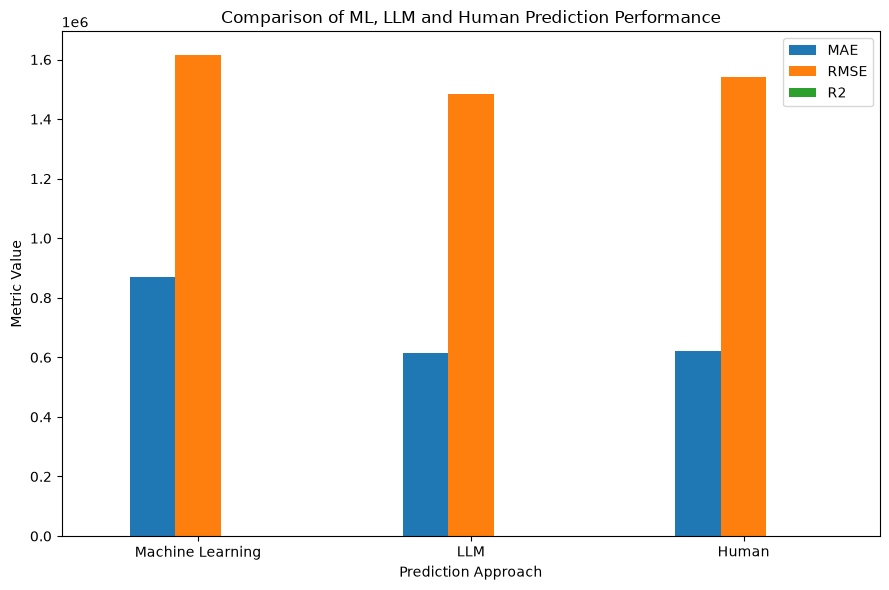

In [37]:
# Compare MAE, RMSE and R2 across ML, LLM and Human approaches

fig, ax = plt.subplots(figsize=(9, 6))

metrics = ["MAE", "RMSE", "R2"]

comparison_results_df.set_index("Approach")[metrics].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Comparison of ML, LLM and Human Prediction Performance")
ax.set_xlabel("Prediction Approach")
ax.set_ylabel("Metric Value")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

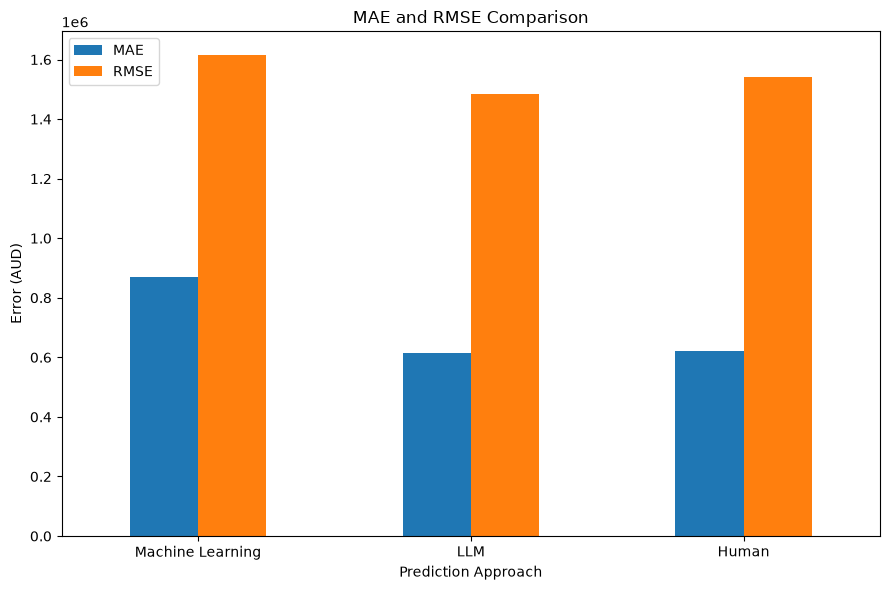

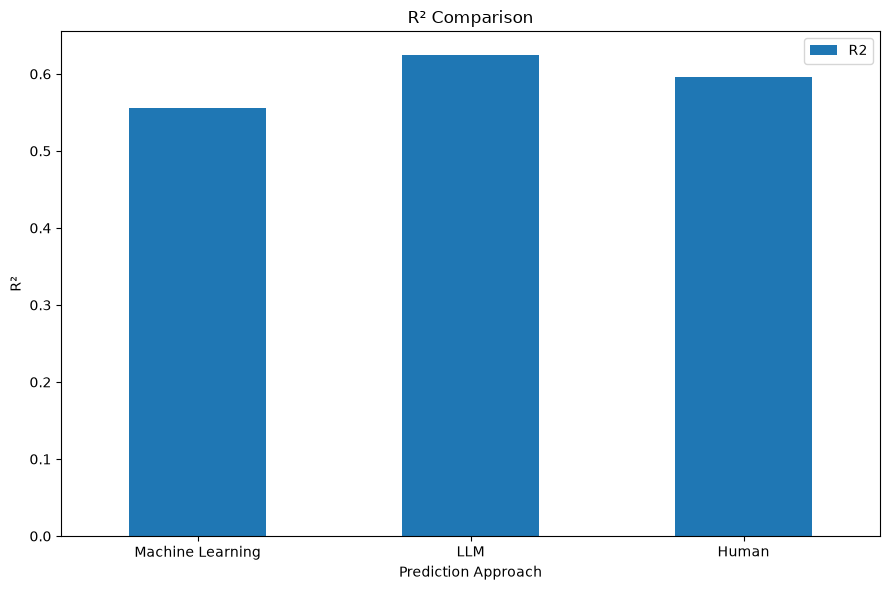

In [38]:
# Compare MAE and RMSE
fig, ax = plt.subplots(figsize=(9, 6))

comparison_results_df.set_index("Approach")[["MAE", "RMSE"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("MAE and RMSE Comparison")
ax.set_xlabel("Prediction Approach")
ax.set_ylabel("Error (AUD)")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


# Compare R2
fig, ax = plt.subplots(figsize=(9, 6))

comparison_results_df.set_index("Approach")[["R2"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("R² Comparison")
ax.set_xlabel("Prediction Approach")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

The comparison of machine learning, LLM and human predictions on 10 held-out properties produced different results from the broader machine-learning evaluation. The LLM achieved the best performance, with an MAE of 616,250 AUD, RMSE of 1,485,484 AUD and R² of 0.62. Human estimates performed very similarly, with an MAE of 621,050 AUD, RMSE of 1,541,209 AUD and R² of 0.60. The machine-learning model had the highest error, with an MAE of 869,273 AUD, RMSE of 1,613,959 AUD and R² of 0.56. This suggests that contextual reasoning can be competitive for a small set of properties, particularly when location and property characteristics provide useful signals. However, the comparison is limited to only 10 properties and should not be interpreted as evidence that LLM or human judgement generally outperforms supervised machine learning. The machine-learning model was trained systematically on the larger training set, whereas the LLM and human estimates relied on contextual judgement. The results therefore highlight the strengths and limitations of each approach rather than identifying one universally superior method.

In [39]:
import joblib

# Save the final Gradient Boosting model
joblib.dump(
    gradient_boosting_model,
    "../app/housing_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [40]:
print("Final model features:")
print(X_train.columns.tolist())

Final model features:
['suburb', 'property_type', 'bedrooms', 'bathrooms', 'parking_spaces', 'listed_area_m2', 'sale_year', 'sale_month']
